In [1]:
# Check python version
#@title Imports (RUN ME!) { display-mode: "form" }
import sys,os
sys.version

import tensorflow as tf
from tensorflow import keras
#from keras.layers import Input

from tensorflow.keras import regularizers
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, GlobalAveragePooling2D, Activation, Input

from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import  EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD


from keras.utils.np_utils import to_categorical
from keras.utils.vis_utils import plot_model

import imgaug as ia
ia.seed(1)

%matplotlib inline
from imgaug.augmentables.bbs import BoundingBox, BoundingBoxesOnImage
from imgaug import augmenters as iaa 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import random
import imageio
import re
import shutil
from PIL import Image
import PIL.Image
PIL.Image.MAX_IMAGE_PIXELS = 969791964129 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2



In [2]:
#!pip install imgaug

In [3]:
#update imagegenerator function
#!pip uninstall keras-preprocessing -y
#!pip install git+https://github.com/keras-team/keras-preprocessing.git
from keras_preprocessing.image import ImageDataGenerator
#from keras.preprocessing.image import ImageDataGenerator


In [ ]:
#path to images
root_dir = "/home/research/bboxes_localize/"
os.listdir(root_dir)

['fences',
 'train-export.csv',
 'Annotations',
 'test-export.csv',
 'annotations.csv']

In [5]:
path = os.path.join(root_dir)

# EDA

In [7]:
# view files
for f in os.listdir(path):
    print(f)

fences
train-export.csv
Annotations
test-export.csv
annotations.csv


In [8]:
labels_df = pd.read_csv(root_dir +"annotations.csv")
labels_df

,filename,xmin,ymin,xmax,ymax,class,width,height
0,Rhodes-University-Location-1-Image-Data%20(11)...,1099.327032,0.000000,5904.000000,3928.000000,single_fence,5904,3936
1,Rhodes-University-Location-1-Image-Data%20(10)...,714.719518,0.000000,5893.275284,3928.000000,single_fence,5904,3936
2,Rhodes-University-Location-1-Image-Data%20(13)...,1484.806474,0.000000,5893.275284,3928.000000,single_fence,5904,3936
3,Rhodes-University-Location-1-Image-Data%20(12)...,1752.662807,0.000000,5887.694943,3928.000000,single_fence,5904,3936
4,Rhodes-University-Location-1-Image-Data%20(1).jpg,17.176985,16.738636,3599.755435,3928.000000,single_fence,5904,3936
...,...,...,...,...,...,...,...,...
205,Rhodes-University-Location-2-Image-Data%20(75)...,0.000000,570.272727,5887.227273,2510.318182,double_fence,5904,3936
206,Rhodes-University-Location-2-Image-Data%20(77)...,16.772727,676.500000,5904.000000,2784.272727,double_fence,5904,3936
207,Rhodes-University-Location-2-Image-Data%20(76)...,5.590909,1073.454545,5898.409091,2387.318182,double_fence,5904,3936
208,Rhodes-University-Location-2-Image-Data%20(78)...,0.000000,1107.000000,5630.045455,2761.909091,double_fence,5904,3936


In [9]:
labels_df.isnull().sum()

filename    0
xmin        0
ymin        0
xmax        0
ymax        0
class       0
width       0
height      0
dtype: int64

# Preprocess the dataset

In [10]:
classes_list = ['single_fence','double_fence']

In [11]:
image_folder = root_dir + "fences/"

In [ ]:
image_folder

In [13]:
def preprocess_dataset(image_folder, classes_list, df, image_size = 300,):
    # Lists that will contain the whole dataset
    labels = []
    boxes = []
    img_list = []
    
    # Get height and width of each image in the datafame
    h = df['height']
    w = df['width']
    
    # Create a copy of the labels in the dataframe
    labels = list(df['class'])
    
    # Create a copy of the bounding box values and also normalize them 
    for x1, y1, x2, y2 in zip(list(df['xmin']/w), list(df['ymin']/h),list(df['xmax']/w), list(df['ymax']/h)):
        arr = [x1, y1, x2, y2]
        boxes.append(arr)
        
    # We loop over each class and its labels 
    for class_folder in classes_list:  
        
        # Set our images directory
        image_dir = os.path.join(image_folder, class_folder)
        
        # Annotation and Image files
        img_files = sorted(os.listdir(image_dir))
        
        
        # Loop over each of the image and its label
        for image_file in img_files:
            
            # Full path Image
            img_path = os.path.join(image_dir, image_file)
            
            # Read the image
            img  = cv2.imread(img_path)
            
            if img is None:
                print('Wrong path:', path)
            else:
                # Resize all images to a fix size
                image = cv2.resize(img, (image_size, image_size))
                
            # Normalize the image by dividing it by 255.0 
            image = image.astype("float") / 255.0
            
            # Append it to the list of images
            img_list.append(image)

    return labels, boxes, img_list

In [14]:
# All images will resized to 300, 300 
image_size = 300

# Get images and bounding boxes
labels, boxes, img_list = preprocess_dataset(image_folder, classes_list, labels_df)
    

We'll Shuffle the data after preprocessing is done.



In [15]:
# Convert labels to integers, then one hot encode them
label_encoder = LabelEncoder()
integer_labels = label_encoder.fit_transform(labels)
onehot_labels = to_categorical(integer_labels)

# Now we need to shuffle the data, so zip all lists and shuffle
combined_list = list(zip(img_list, boxes, onehot_labels))
random.shuffle(combined_list)

# Extract back the contents of each list
img_list, boxes, onehot_labels = zip(*combined_list)

print('All Done')

All Done


## **Visualize the Data with its Annotations**
Here we will pick some random images from each class and draw its associated bounding boxes over it. This way you’ll be able to visualize the data and make sure that your preprocessing steps were done correctly.

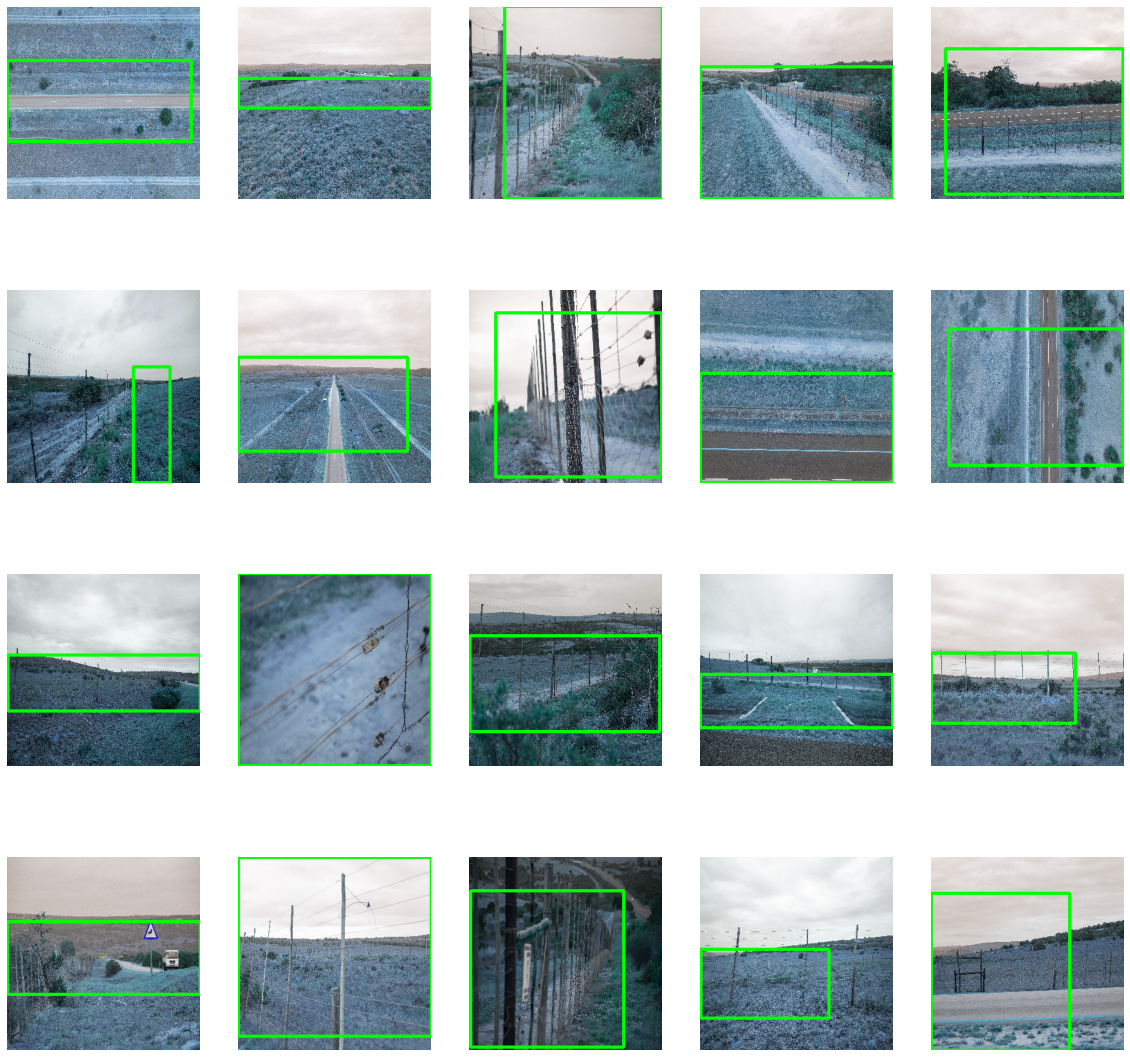

In [16]:
# Create a Matplotlib figure
plt.figure(figsize=(20,20));

# Generate a random sample of images each time the cell is run 
random_range = random.sample(range(1, len(img_list)), 20)

for iteration, i in enumerate(random_range, 1):

    # Bounding box of each image
    a1, b1, a2, b2 = boxes[i];

    # Rescaling the boundig box values to match the image size
    x1 = a1 * image_size
    x2 = a2 * image_size
    y1 = b1 * image_size
    y2 = b2 * image_size

    # The image to visualize
    image = img_list[i]

    # Draw bounding boxes on the image
    cv2.rectangle(image, (int(x1),int(y1)),
          (int(x2),int(y2)),
                  (0,255,0),
                  3);
    
    # Clip the values to 0-1 and draw the sample of images
    image = np.clip(img_list[i], 0, 1)
    plt.subplot(4, 5, iteration);
    plt.imshow(image);
    plt.axis('off');

## **Split the Data into Train and Validation Set**
Now we would have 3 lists, one list containing all images, the second one contains all class labels in one hot encoded format and the third one list contains scaled bounding box coordinates. Let’s split our data to create a training and validation set. It’s important that you shuffle your data before the split which we have already done.


In [17]:
# Split the data of images, labels and their annotations
train_images, val_images, train_labels, \
val_labels, train_boxes, val_boxes = train_test_split( np.array(img_list), 
                np.array(onehot_labels), np.array(boxes), test_size = 0.1, 
                random_state = 43)

print('Total Training Images: {}, Total Validation Images: {}'.format(
    len(train_images), len(val_images) ))

Total Training Images: 189, Total Validation Images: 21


## **Construct the Multi Output Model**
Now it’s time to create our Multi Output model. We won’t be training from scratch but we will use transfer learning. The model we’ll use is NasnetMobile. This is a really efficient model with a good balance of speed and accuracy,  It was created through Neural Architecture Research (NAS) which is an emerging field of AutoML.

We’ll first download the model but exclude the top, since we’ll be adding our own custom top


# Let's create a function that will construct our model
def create_model(no_of_classes):
    
    input_layer = Input(shape = (300,300,3))#Input(shape=(len(train_images),))

    
    # Create our Classification Head, final layer contains 
    # Ouput units = no. classes
    class_prediction = Dense(256, activation="relu")(input_layer)
    class_prediction = Dense(128, activation="relu")(class_prediction )
    class_prediction = Dropout(0.2)(class_prediction)
    class_prediction = Dense(64, activation="relu")(class_prediction)
    class_prediction = Dropout(0.2)(class_prediction )
    class_prediction = Dense(32, activation="relu")(class_prediction)
    class_prediction = Dense(no_of_classes, activation='softmax',
                             name="class_output")(class_prediction)

    # Create Our Localization Head, final layer contains 4 nodes for x1,y1,x2,y2
    # Respectively.
    box_output = Dense(256, activation="relu")(input_layer)
    box_output = Dense(128, activation="relu")(box_output)
    box_output = Dropout(0.2)(box_output )

    box_output = Dense(64, activation="relu")(box_output)
    box_output = Dropout(0.2)(box_output )

    box_output = Dense(32, activation="relu")(box_output)
    box_predictions = Dense(4, activation='sigmoid',
                            name= "box_output")(box_output)

    # Now combine the two heads
    model = keras.Model(inputs=input_layer, outputs= [box_predictions, 
                                                   class_prediction])

    return model

# Create the model for 3 classes, Elephant, Butterfly, Cougar-Face
model = create_model(2); print("Model Created")

In [18]:
# Load the NasNetMobile Model, make sure to exclude the top for transfer learning
N_mobile = tf.keras.applications.NASNetMobile( input_tensor = Input(
    shape=(image_size, image_size, 3)), 
    include_top=False, 
    weights='imagenet')

In [19]:
# Let's create a function that will construct our model
def create_model(no_of_classes):

    # Freeze the whole model
    N_mobile.trainable = False
    
    # Start by taking the output feature maps from NASNETMobile
    base_model_output = N_mobile.output
    
    # Convert to a single-dimensional vector by Global Average Pooling.

    # We could also use Flatten()(x) but GAP is more effective, it reduces 
    # Parameters and controls overfitting.
    flattened_output = GlobalAveragePooling2D()(base_model_output)

    # Create our Classification Head, final layer contains 
    # Ouput units = no. classes
    class_prediction = Dense(256, activation="relu")(flattened_output)
    class_prediction = Dense(128, activation="relu")(class_prediction )
    class_prediction = Dropout(0.2)(class_prediction)
    class_prediction = Dense(64, activation="relu")(class_prediction)
    class_prediction = Dropout(0.2)(class_prediction )
    class_prediction = Dense(32, activation="relu")(class_prediction)
    class_prediction = Dense(no_of_classes, activation='softmax',
                             name="class_output")(class_prediction)

    # Create Our Localization Head, final layer contains 4 nodes for x1,y1,x2,y2
    # Respectively.
    box_output = Dense(256, activation="relu")(flattened_output)
    box_output = Dense(128, activation="relu")(box_output)
    box_output = Dropout(0.2)(box_output )

    box_output = Dense(64, activation="relu")(box_output)
    box_output = Dropout(0.2)(box_output )

    box_output = Dense(32, activation="relu")(box_output)
    box_predictions = Dense(4, activation='sigmoid',
                            name= "box_output")(box_output)

    # Now combine the two heads
    model = keras.Model(inputs=N_mobile.input, outputs= [box_predictions, 
                                                   class_prediction])

    return model

# Create the model for 3 classes, Elephant, Butterfly, Cougar-Face
model = create_model(2); print("Model Created")

Model Created


p#lot_model(model, to_file='model_plot.png', show_shapes=True, 
           show_layer_names=True)

## **Compile & Train the Model**


Now here are a couple of things that you need to do. If this was a single output model you would have just defined a loss, a metric and an optimizer and compiled the model. Since we’re dealing with a multi output model that outputs two totally different things so we need to use seperate loss and separate metrics for both of these output branches.

Remember when we were creating the model we actually assigned names to our two output branches by doing that now we can easily refer to the name of an output branch and then assign it a specific loss or metric, just like a python dictionary. 


In [20]:
# Here for each head we will define a different loss, we will define it 
# Like a dictionary.

# For classification we will have cateogirical crossentropy
# For the bouding boxes we will have mean squared error
losses = { 
    "box_output": "mean_squared_error",
    "class_output": "categorical_crossentropy"
    }

# Here you can give more or less weightage to each loss. 

# If you think that detection is harder then the classification then you can 
# Try assinging it more weight
loss_weights = {
    "box_output": 1.0, 
    "class_output": 1.0
    }

# Set the Metrics
# For the class labels we want to know the Accuracy
# And for the bounding boxes we need to know the Mean squared error
metrics = {
    'class_output': 'accuracy', 
    'box_output':  'mse'
    }

# We will be using early stopping to stop the model if total val loss does not
# Decrease by 0.001 in 40 epochs
stop = EarlyStopping(monitor = "val_loss", min_delta = 0.0001, patience = 40, 
                    restore_best_weights = True
                     )

# Change the learning rate according to number of epochs to boost learning
reduce_lr = ReduceLROnPlateau(monitor = "val_loss", factor = 0.0002, 
                              patience = 30, min_lr = 1e-7, verbose = 1)

# Initialize Optimizer
opt = SGD( learning_rate = 1e-3, momentum = 0.9)

# Compile the model with Adam optimizer
model.compile(optimizer = opt, loss = losses, loss_weights = loss_weights, 
    metrics = metrics)

### **Start Training:**
When you're dealing with a multi output model then you need to assingn individual branches labels seperately like a dictionary. 

In [21]:
# Train the Model
history = model.fit(x = train_images, 
                    y= {
                        "box_output": train_boxes, 
                        "class_output": train_labels
                        }, 
                    validation_data=(
                        val_images, 
                        {
                          "box_output": val_boxes, 
                          "class_output": val_labels
                          }), batch_size = 32, epochs = 500, 
                    callbacks=[reduce_lr, stop])

Epoch 1/500
6/6 [==============================] - 53s 3s/step - loss: 0.8647 - box_output_loss: 0.1899 - class_output_loss: 0.6748 - box_output_mse: 0.1899 - class_output_accuracy: 0.5661 - val_loss: 0.8638 - val_box_output_loss: 0.1797 - val_class_output_loss: 0.6842 - val_box_output_mse: 0.1797 - val_class_output_accuracy: 0.5238
Epoch 2/500
6/6 [==============================] - 6s 1s/step - loss: 0.8718 - box_output_loss: 0.1843 - class_output_loss: 0.6875 - box_output_mse: 0.1843 - class_output_accuracy: 0.5185 - val_loss: 0.8601 - val_box_output_loss: 0.1697 - val_class_output_loss: 0.6904 - val_box_output_mse: 0.1697 - val_class_output_accuracy: 0.5714
Epoch 3/500
6/6 [==============================] - 6s 979ms/step - loss: 0.8517 - box_output_loss: 0.1744 - class_output_loss: 0.6773 - box_output_mse: 0.1744 - class_output_accuracy: 0.5556 - val_loss: 0.8537 - val_box_output_loss: 0.1573 - val_class_output_loss: 0.6964 - val_box_output_mse: 0.1573 - val_class_output_accuracy: 0

6/6 [==============================] - 5s 940ms/step - loss: 0.5209 - box_output_loss: 0.0519 - class_output_loss: 0.4691 - box_output_mse: 0.0519 - class_output_accuracy: 0.8095 - val_loss: 0.7558 - val_box_output_loss: 0.0385 - val_class_output_loss: 0.7173 - val_box_output_mse: 0.0385 - val_class_output_accuracy: 0.5238
Epoch 26/500
6/6 [==============================] - 5s 924ms/step - loss: 0.5174 - box_output_loss: 0.0492 - class_output_loss: 0.4682 - box_output_mse: 0.0492 - class_output_accuracy: 0.8095 - val_loss: 0.7530 - val_box_output_loss: 0.0364 - val_class_output_loss: 0.7166 - val_box_output_mse: 0.0364 - val_class_output_accuracy: 0.5238
Epoch 27/500
6/6 [==============================] - 5s 904ms/step - loss: 0.5205 - box_output_loss: 0.0466 - class_output_loss: 0.4739 - box_output_mse: 0.0466 - class_output_accuracy: 0.8095 - val_loss: 0.7384 - val_box_output_loss: 0.0346 - val_class_output_loss: 0.7039 - val_box_output_mse: 0.0346 - val_class_output_accuracy: 0.5238

6/6 [==============================] - 5s 923ms/step - loss: 0.2732 - box_output_loss: 0.0284 - class_output_loss: 0.2448 - box_output_mse: 0.0284 - class_output_accuracy: 0.9206 - val_loss: 0.9428 - val_box_output_loss: 0.0229 - val_class_output_loss: 0.9199 - val_box_output_mse: 0.0229 - val_class_output_accuracy: 0.6667
Epoch 50/500
6/6 [==============================] - 5s 904ms/step - loss: 0.2781 - box_output_loss: 0.0279 - class_output_loss: 0.2503 - box_output_mse: 0.0279 - class_output_accuracy: 0.9153 - val_loss: 0.8976 - val_box_output_loss: 0.0228 - val_class_output_loss: 0.8748 - val_box_output_mse: 0.0228 - val_class_output_accuracy: 0.6190
Epoch 51/500
6/6 [==============================] - 5s 922ms/step - loss: 0.2695 - box_output_loss: 0.0285 - class_output_loss: 0.2409 - box_output_mse: 0.0285 - class_output_accuracy: 0.9312 - val_loss: 0.8943 - val_box_output_loss: 0.0228 - val_class_output_loss: 0.8715 - val_box_output_mse: 0.0228 - val_class_output_accuracy: 0.6190

## **Plot Model’s Loss & Accuracy Curves**
Now we had seperate losses and sperate metrics for differnt branches, on top of that we used a validation set. We're now dealing with 10 total metrics. Let's visualize and understand these by plotting them.

In [22]:
def plot(var1, var2, plot_name):
    # Get the loss metrics from the trained model
    c1 = history.history[var1]
    c2 = history.history[var2]
    
    epochs = range(len(c1))
    
    # Plot the metrics
    plt.plot(epochs, c1, 'b', label=var1)
    plt.plot(epochs, c2, 'r', label=var2)
    plt.title(str(plot_name))
    plt.legend()

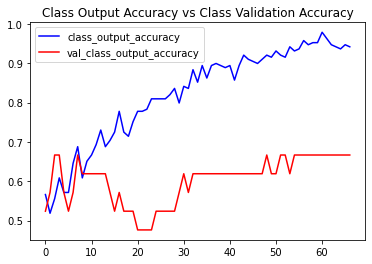

In [23]:
plot('class_output_accuracy','val_class_output_accuracy','Class Output Accuracy vs Class Validation Accuracy')

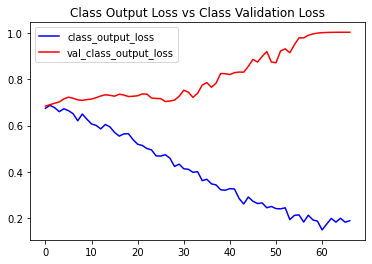

In [24]:
plot('class_output_loss','val_class_output_loss','Class Output Loss vs Class Validation Loss')

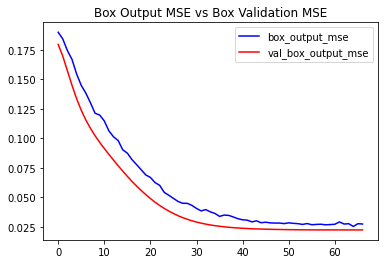

In [25]:
plot('box_output_mse','val_box_output_mse','Box Output MSE vs Box Validation MSE')

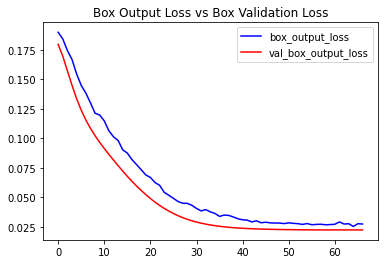

In [26]:
plot('box_output_loss','val_box_output_loss','Box Output Loss vs Box Validation Loss')

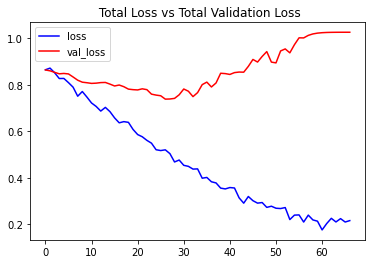

In [27]:
# These are the most important metrics in telling us how our model is doing
plot('loss','val_loss',' Total Loss vs Total Validation Loss')

### **Save Your Model**
You should save your model for future runs.

In [28]:
# Save your model here in .h5 format.
model.save('fences.h5')

# Load the saved model
# model = load_model('fences.h5')

/home/nandutu/anaconda3/lib/python3.8/site-packages/keras/utils/generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


## **Test your model on New Images**
In this step we will create a function that will use the model to predict on new images.

In [29]:
# Enter your class names in this list
global label_names

# Must be same as Annotations list we used to choose the data
label_names = sorted(classes_list)

### **Predict Function**
Here we will create a function that [that](https:// [link text](https:// [link text](https://))) will use the model to predict on new images.


In [30]:
# We will use this function to make prediction on images.
def predict(image, returnimage = False,  scale = 0.9):
    
    # Before we can make a prediction we need to preprocess the image.
    processed_image = preprocess(image)
    
    # Now we can use our model for prediction
    results = model.predict(processed_image)
    
    # Now we need to postprocess these results.
    # After postprocessing, we can easily use our results
    label, (x1, y1, x2, y2), confidence = postprocess(image, results)
    
    # Now annotate the image
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 100), 2)
    cv2.putText(
      image,'{}'.format(label, confidence), 
      (x1, y2 + int(35 * scale)), 
      cv2.FONT_HERSHEY_COMPLEX, scale,
      (200, 55, 100),
      2
      )
    
    # Show the Image with matplotlib
    plt.figure(figsize=(10,10))
    plt.imshow(image[:,:,::-1])

### **Preprocessing Funciton**
This function will preprocess new images in the same way we did initially before training.

In [31]:
# This function will preprocess images.
def preprocess(img, image_size = 300):
  
    image = cv2.resize(img, (image_size, image_size))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image.astype("float") / 255.0 

    # Expand dimensions as predict expect image in batches
    image = np.expand_dims(image, axis=0) 
    return image

### **Post Processing Function**
After the prediction, you need to do some postprocessing in order to extract the class label and the real boudning box coordinates.

In [32]:
def postprocess(image, results):

    # Split the results into class probabilities and box coordinates
    bounding_box, class_probs = results

    # First let's get the class label

    # The index of class with the highest confidence is our target class
    class_index = np.argmax(class_probs)
  
    # Use this index to get the class name.
    class_label = label_names[class_index]

    # Now you can extract the bounding box too.

    # Get the height and width of the actual image
    h, w = image.shape[:2]

    # Extract the Coordinates
    x1, y1, x2, y2 = bounding_box[0]

    # Convert the coordinates from relative (i.e. 0-1) to actual values
    x1 = int(w * x1)
    x2 = int(w * x2)
    y1 = int(h * y1)
    y2 = int(h * y2)

    # return the lable and coordinates
    return class_label, (x1,y1,x2,y2),class_probs

Now that we created all the required functions, lets test our model on new images




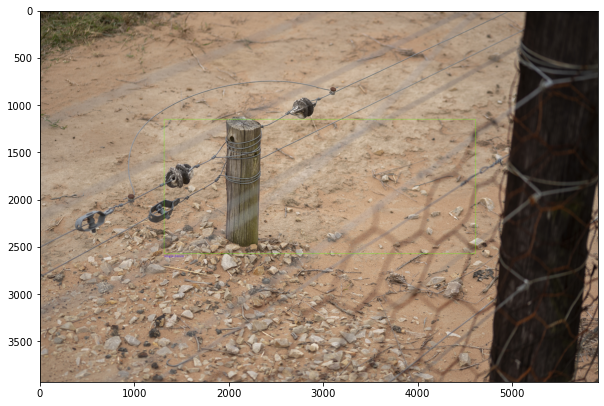

In [33]:
image = cv2.imread(root_dir+'fences/single_fence/Rhodes-University-Location-1-Image-Data%20(3).jpg' )
predict(image, scale = 1)

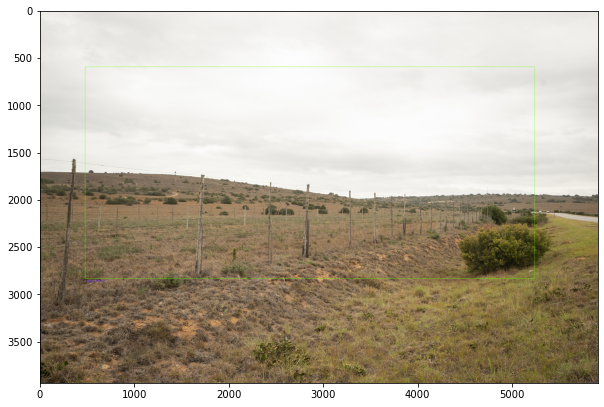

In [34]:
image = cv2.imread(root_dir+'fences/double_fence/Rhodes-University-Location-2-Image-Data%20(3).jpg' )
predict(image, scale = 1)